In [25]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import datetime
import itertools

import matplotlib.dates as mdates
import numpy.ma as ma
import CRPS.CRPS as pscore
from torch.utils.data import Dataset
from torchvision import datasets
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.image as mpimg
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from sklearn.model_selection import KFold
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import DataLoader
import pickle as pkl

In [ ]:
import pandas as pd

# Load metadata.parquet file
metadata_df = pd.read_parquet("/home/ubuntu/PVOutputPrediction/preprocessing/data/data_forecast4/metadata_test/metadata.parquet")

In [27]:
print(times_test.shape)

(14003,)


In [28]:
import pandas as pd

# Load metadata.parquet file
metadata_df = pd.read_parquet("D:\\PVOutputPrediction\\preprocessing\\data\\data_forecast4\\metadata_trainval\\metadata3.parquet")

In [29]:
print(metadata_df["cloudiness"][149679])


0.041151578546976035


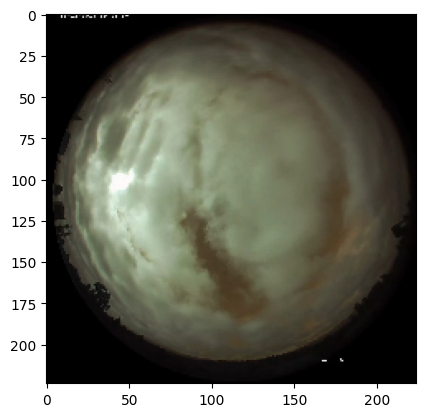

0.7394922023583113


In [55]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
def load_mp4_to_numpy(mp4_path, max_frames=None):
    """
    Loads an mp4 file and converts it to a numpy array of frames.
    
    Args:
        mp4_path (str): Path to the mp4 video.
        max_frames (int, optional): Maximum number of frames to load. If None, load all frames.
        
    Returns:
        frames (np.ndarray): Array of shape (num_frames, H, W, 3) with dtype=np.uint8.
    """
    cap = cv2.VideoCapture(mp4_path)
    frames = []
    count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        # Convert BGR (OpenCV default) to RGB for matplotlib
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)
        count += 1
        if max_frames is not None and count >= max_frames:
            break
    cap.release()
    if frames:
        return np.stack(frames)
    else:
        return np.array([])

def show_video_frames(frames, n_display=5, title_base='Frame'):
    """
    Display several frames from a video (numpy array) using matplotlib.
    
    Args:
        frames (np.ndarray): Video frames with shape (num_frames, H, W, 3).
        n_display (int): Number of frames to display (evenly spaced).
        title_base (str): String base for subplot titles.
    """
    if len(frames) == 0:
        print("No frames to display.")
        return
    n_frames = len(frames)
    idxs = np.linspace(0, n_frames - 1, num=min(n_display, n_frames), dtype=int)
    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(idxs):
        plt.subplot(1, len(idxs), i+1)
        plt.imshow(frames[idx])
        plt.title(f"{title_base} {idx}")
        plt.axis('off')
    plt.show()

# Example usage:
idx = 130971
mp4_path = f"D:/PVOutputPrediction/preprocessing/data/data_forecast4/videos_trainval/sequence_{idx:06d}.mp4"

vid_frames = load_mp4_to_numpy(mp4_path)

plt.imshow(vid_frames[0])
plt.show()
print(metadata_df["cloudiness"][idx])

In [ ]:
# formulate sunny and cloudy test days
sunny_dates = [(2017,9,15),(2017,10,6),(2017,10,22),(2018,2,16),(2018,6,12),(2018,6,23),(2019,1,25),(2019,6,23),(2019,7,14),(2019,10,14)]
cloudy_dates = [(2017,9,6),(2017,11,4),(2017,12,29),
        (2018,5,31),(2018,7,12),(2018,10,3),
        (2019,1,26),(2019,5,27),(2019,9,7),(2019,10,19)]
sunny_dates_test = [datetime.date(day[0],day[1],day[2]) for day in sunny_dates]
cloudy_dates_test = [datetime.date(day[0],day[1],day[2]) for day in cloudy_dates]

dates_test = np.asarray([times.date() for times in times_test])

## generate mask for the sunny days
mask = np.zeros(len(pv_log_test),dtype=bool)
for i in sunny_dates_test:
    mask[np.where(dates_test==i)[0]]=1

## apply the mask to the dataset
times_test_sunny = times_test[mask]
pv_log_test_sunny = pv_log_test[mask]
#images_log_test_sunny = images_log_test[mask]
prediction_ensemble_sunny = prediction_ensemble[mask]
print("times_test_sunny.shape:",times_test_sunny.shape)

times_test_cloudy = times_test[~mask]
pv_log_test_cloudy = pv_log_test[~mask]
#images_log_test_cloudy = images_log_test[~mask]
prediction_ensemble_cloudy = prediction_ensemble[~mask]
print("times_test_cloudy.shape:",times_test_cloudy.shape)

NameError: name 'pv_log_test' is not defined

In [ ]:
# visualization of forecast predictions
dates_test = np.array([dtinfo.date() for dtinfo in times_test])
hours_test = np.array([dtinfo.time() for dtinfo in times_test])

f,axarr = plt.subplots(10,1,sharex=False, sharey = True)
xfmt = mdates.DateFormatter('%H')
fmt_date = datetime.date(2000,1,1)

green = '#8AB8A7'
red = '#8C1515'
blue = '#67AFD2'
grey =  '#B6B1A9'
black = '#2E2D29'
red = '#8C1515'
light_blue = '#67AFD2'
dark_blue = '#016895'
blue = '#4298B5'
black = '#2E2D29'
dark_red = '#820000'
light_red = '#B83A4B'

for i,date in enumerate(cloudy_dates_test):
    ax = axarr[i]
    date_mask = (dates_test == date)
    hours_xaxis= [datetime.datetime.combine(fmt_date, hour) for hour in hours_test[date_mask]] 
    
    rmse = np.sqrt(np.mean(np.square((pv_log_test[date_mask]-prediction_ensemble[date_mask]))))
    mae = np.mean(np.abs((pv_log_test[date_mask]-prediction_ensemble[date_mask])))
    
    ax.plot(hours_xaxis, pv_log_test[date_mask], linewidth = 1,color=black, label = 'Ground truth')
    ax.plot(hours_xaxis, prediction_ensemble[date_mask],linewidth = 1.5,label = 'UNet nowcast mean',color=red,markerfacecolor="None")
    #ax.fill_between(hours_xaxis, percent5_prediction[date_mask], percent95_prediction[date_mask], color=light_blue, alpha=0.5, label = '5~95%tile pred.')
    #ax.fill_between(hours_xaxis, percent25_prediction[date_mask], percent75_prediction[date_mask], color=blue, alpha=0.75, label = '25~75%tile pred.')
    ax.set_ylabel('PV output (kW)')
    ax.xaxis.set_major_formatter(xfmt)
    ax.text(0.85,0.85,'Cloudy_'+str(i+1), transform=ax.transAxes)
    #ax.text(0.05,0.65,"RMSE: {0:.2f}\nMAE: {1:.2f}\nFS: {2:.2f}%".format(rmse,mae,fs),transform=ax.transAxes)
    ax.text(0.05,0.65,"RMSE: {0:.2f}\nMAE: {1:.2f}".format(rmse,mae),transform=ax.transAxes)

axarr[0].set_ylim(0, 30)
axarr[0].legend(bbox_to_anchor= [.5,1.3], loc = 'upper center', ncol = 4)
axarr[-1].set_xlabel('Hour of day')

f.set_size_inches(10,30)    
plt.show()